# Group04 — SOMLAP — Track 3, Task 3
## Explainability with Grad-CAM and LIME

**Authors:** Md. Rafiqul Islam (2026-2-74-025); Ahanaf Shahadat Taseen (2026-2-74-033); Reasad Mahmood (2026-2-74-012).

The final CNN+CBAM model selected in the ablation experiment is examined with
Grad-CAM and LIME. Both methods are evaluated on one correctly classified sample
and one error from the fixed held-out set.


In [1]:
# ==========================================================
# CELL 1 — Imports
# ==========================================================

import os
import time
import random
import warnings
import json
import joblib
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from IPython.display import display, Image
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization, Dropout, Dense,
    GlobalAveragePooling2D, Input, Activation, Rescaling
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

from scipy.stats import binomtest, wilcoxon

import subprocess, sys
try:
    from lime import lime_image
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "lime==0.2.0.1"])
    from lime import lime_image

TensorFlow: 2.20.0
NumPy: 2.0.2
Pandas: 2.3.3


In [2]:
# ==========================================================
# CELL 2 — Kaggle GPU and Reproducibility
# ==========================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
if not gpus:
    raise RuntimeError(
        "No GPU detected. Select GPU T4 x2 or GPU P100 in Kaggle Settings."
    )

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

if len(gpus) > 1:
    strategy = tf.distribute.MirroredStrategy()
else:
    strategy = tf.distribute.OneDeviceStrategy("/GPU:0")

NUM_REPLICAS = strategy.num_replicas_in_sync
BATCH_SIZE = 32
PER_REPLICA_BATCH_SIZE = BATCH_SIZE // NUM_REPLICAS
EPOCHS = 60

print("Physical GPUs:", len(gpus))
print("Strategy:", type(strategy).__name__)
print("Replicas:", NUM_REPLICAS)
print("Global batch size:", BATCH_SIZE)
print("Maximum epochs:", EPOCHS)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Physical GPUs: 2
Strategy: MirroredStrategy
Replicas: 2
Global batch size: 32
Maximum epochs: 60


I0000 00:00:1788063735.100329      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788063735.103586      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
# ==========================================================
# CELL 3 — Load SOMLAP Dataset
# Auto-detects the CSV path under /kaggle/input/
# If running locally, set LOCAL_PATH below.
# ==========================================================
import glob, os

# ── Kaggle: search for the CSV automatically ──
candidates = glob.glob("/kaggle/input/**/*.csv", recursive=True)
somlap_candidates = [p for p in candidates if "somlap" in p.lower() or "SOMLAP" in p]

if somlap_candidates:
    DATA_PATH = somlap_candidates[0]
    print(f"Found dataset at: {DATA_PATH}")
else:
    # Fallback: list all CSVs found so user can pick
    print("SOMLAP CSV not auto-detected. CSVs found under /kaggle/input/:")
    for p in candidates:
        print(f"  {p}")
    # ── Set this manually if auto-detect fails ──
    DATA_PATH = "/kaggle/input/SOMLAP DATASET.csv"
    print(f"\nUsing fallback path: {DATA_PATH}")
    print("If this is wrong, set DATA_PATH manually above.")

df = pd.read_csv(DATA_PATH)
TARGET = "class"
X_all = df.drop(columns=[TARGET])
y_all = df[TARGET]

print(f"\nDataset Loaded: {df.shape}")
print(f"Classes : {sorted(y_all.unique())}")
print(f"Benign  : {(y_all==0).sum():,}   Malware: {(y_all==1).sum():,}")

# Aliases used in Task 2
X = X_all
y = y_all

print(f"Feature matrix: {X.shape}")
display(df.head(3))

Found dataset at: /kaggle/input/datasets/ravikiranvarmap/somlap-data-set/SOMLAP DATASET.csv

Dataset Loaded: (51408, 109)
Classes : [np.int64(0), np.int64(1)]
Benign  : 31,600   Malware: 19,808
Feature matrix: (51408, 108)


,blp,Fp,Rn,Prhdr,Minpar,Maxpar,Ivalss,Ivalsp,doscksum,Iip,...,bss_viraddr,bss_datsize,bss_ptrrawdat,bss_char,bss_entro,bss_phyaddr.1,bss_virsize.1,bss_viraddr.1,bss_char.1,class
0,144,3,0,4,0,65535,0,184,0,0,...,0,0,0,0,0.0,0,0,0,0,0
1,144,3,0,4,0,65535,0,184,0,0,...,0,0,0,0,0.0,0,0,0,0,0
2,144,3,0,4,0,65535,0,184,0,0,...,0,0,0,0,0.0,0,0,0,0,0


In [4]:
# ==========================================================
# CELL 4 — Feature / Target Split
# ==========================================================
TARGET = "class"
X = df.drop(columns=[TARGET])
y = df[TARGET]
print(f"Features: {X.shape[1]}  Samples: {len(X):,}")
print(f"Benign  : {(y==0).sum():,}  Malware: {(y==1).sum():,}")
print(f"Ratio   : {(y==0).sum()/(y==1).sum():.2f}:1")

Features: 108  Samples: 51,408
Benign  : 31,600  Malware: 19,808
Ratio   : 1.60:1


---
## Leakage-aware split

Exact duplicate SOMLAP feature vectors are treated as one group. Every occurrence
of an identical vector is assigned entirely to training, validation, or testing.
This prevents duplicate memorization across splits while retaining all samples.

The same seed and grouping algorithm are used in the final baseline notebook.

In [5]:
# ==========================================================
# CELL 5 — Duplicate-Group 70/15/15 Split
# ==========================================================

feature_group = pd.util.hash_pandas_object(X, index=False).astype("uint64")
group_table = pd.DataFrame({"group": feature_group, "class": y})

group_label_counts = group_table.groupby("group")["class"].nunique()
if int((group_label_counts > 1).sum()) != 0:
    raise ValueError("Identical feature vectors with conflicting labels were found.")

unique_groups = group_table.drop_duplicates("group")
train_groups, temp_groups = train_test_split(
    unique_groups, test_size=0.30, random_state=SEED,
    stratify=unique_groups["class"]
)
valid_groups, test_groups = train_test_split(
    temp_groups, test_size=0.50, random_state=SEED,
    stratify=temp_groups["class"]
)

train_group_ids = set(train_groups["group"])
valid_group_ids = set(valid_groups["group"])
test_group_ids = set(test_groups["group"])

train_mask = feature_group.isin(train_group_ids)
valid_mask = feature_group.isin(valid_group_ids)
test_mask = feature_group.isin(test_group_ids)

X_train, y_train = X.loc[train_mask].copy(), y.loc[train_mask].copy()
X_valid, y_valid = X.loc[valid_mask].copy(), y.loc[valid_mask].copy()
X_test, y_test = X.loc[test_mask].copy(), y.loc[test_mask].copy()

assert not (train_group_ids & valid_group_ids)
assert not (train_group_ids & test_group_ids)
assert not (valid_group_ids & test_group_ids)
assert len(X_train) + len(X_valid) + len(X_test) == len(X)

split_df = pd.DataFrame({
    "Split": ["Training", "Validation", "Testing"],
    "Samples": [len(X_train), len(X_valid), len(X_test)],
    "Unique groups": [len(train_group_ids), len(valid_group_ids), len(test_group_ids)],
    "Benign": [(y_train == 0).sum(), (y_valid == 0).sum(), (y_test == 0).sum()],
    "Malware": [(y_train == 1).sum(), (y_valid == 1).sum(), (y_test == 1).sum()]
})

print("Exact duplicate rows grouped before splitting:", len(X) - feature_group.nunique())
print("Feature-group overlap across splits: 0")
display(split_df)

Exact duplicate rows grouped before splitting: 14367
Feature-group overlap across splits: 0


,Split,Samples,Unique groups,Benign,Malware
0,Training,36027,25928,22108,13919
1,Validation,7651,5556,4739,2912
2,Testing,7730,5557,4753,2977


In [6]:
# ==========================================================
# CELL 6 — Training-Only Scaling with Safe Clipping
# ==========================================================

scaler = StandardScaler()
X_tr_std = scaler.fit_transform(X_train)
X_va_std = scaler.transform(X_valid)
X_te_std = scaler.transform(X_test)

px_scaler = MinMaxScaler(feature_range=(0, 255))
X_tr_px = px_scaler.fit_transform(X_tr_std)
X_va_px = px_scaler.transform(X_va_std)
X_te_px = px_scaler.transform(X_te_std)

X_tr_px = np.clip(X_tr_px, 0, 255).astype(np.uint8)
X_va_px = np.clip(X_va_px, 0, 255).astype(np.uint8)
X_te_px = np.clip(X_te_px, 0, 255).astype(np.uint8)

print("Scaler fitted only on training data")
print("Train range:", X_tr_px.min(), "to", X_tr_px.max())
print("Validation range:", X_va_px.min(), "to", X_va_px.max())
print("Test range:", X_te_px.min(), "to", X_te_px.max())

Scaler fitted only on training data
Train range: 0 to 255
Validation range: 0 to 255
Test range: 0 to 255


Train: (36027, 12, 9)  Valid: (7651, 12, 9)  Test: (7730, 12, 9)


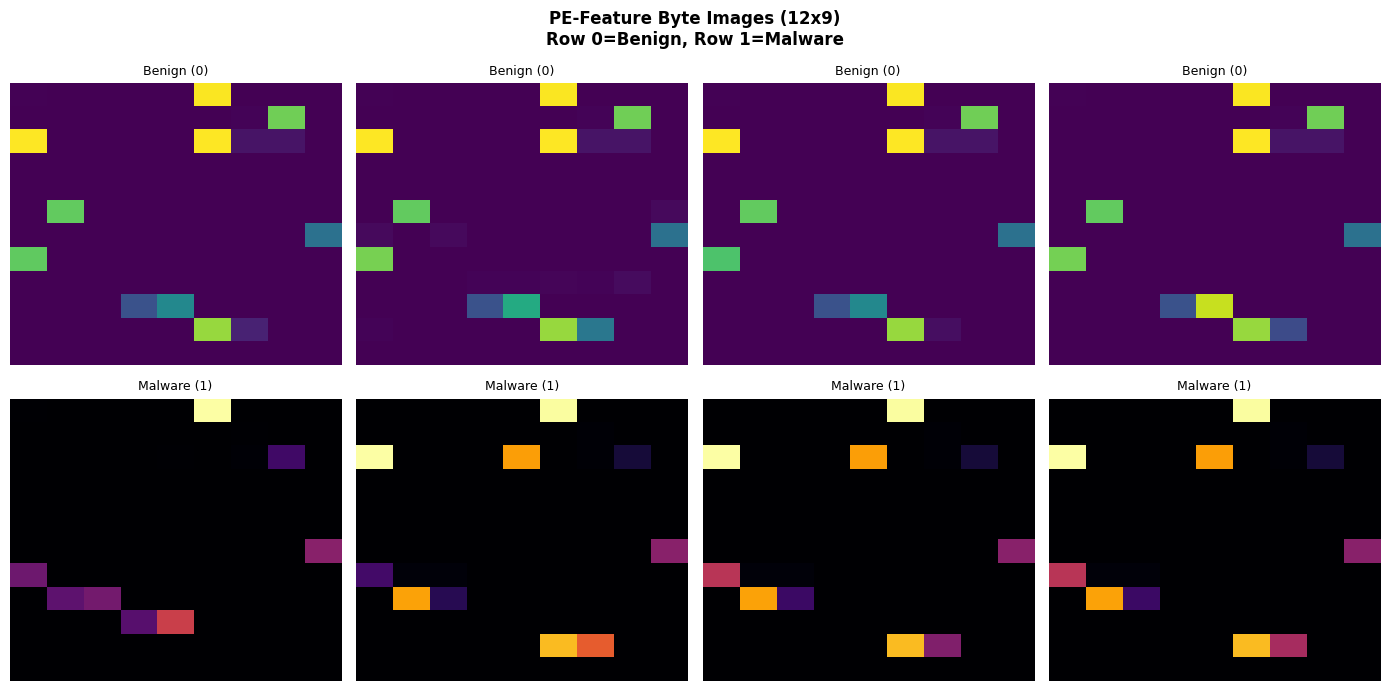

Reading: Benign and malware samples show distinct pixel patterns,
especially in TEXT-section rows (entropy, size fields).


In [7]:
# ==========================================================
# CELL 7 — Reshape to 12x9 Byte Images (108 = 12*9)
# ==========================================================
IMG_H, IMG_W = 12, 9
X_tr_img = X_tr_px.reshape(-1, IMG_H, IMG_W)
X_va_img = X_va_px.reshape(-1, IMG_H, IMG_W)
X_te_img = X_te_px.reshape(-1, IMG_H, IMG_W)

print(f"Train: {X_tr_img.shape}  Valid: {X_va_img.shape}  Test: {X_te_img.shape}")

# Visualise samples
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("PE-Feature Byte Images (12x9)\nRow 0=Benign, Row 1=Malware",
             fontsize=12, fontweight='bold')
bg = np.where(y_train.values == 0)[0][:4]
ml = np.where(y_train.values == 1)[0][:4]
for i, idx in enumerate(bg):
    axes[0,i].imshow(X_tr_img[idx], cmap="viridis", aspect="auto")
    axes[0,i].set_title("Benign (0)", fontsize=9); axes[0,i].axis("off")
for i, idx in enumerate(ml):
    axes[1,i].imshow(X_tr_img[idx], cmap="inferno", aspect="auto")
    axes[1,i].set_title("Malware (1)", fontsize=9); axes[1,i].axis("off")
plt.tight_layout()
plt.savefig("byte_image_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Reading: Benign and malware samples show distinct pixel patterns,")
print("especially in TEXT-section rows (entropy, size fields).")

In [8]:
# CELL 8 - Dataset factory with semantically safe augmentation
IMG_SIZE = 96
AUTOTUNE = tf.data.AUTOTUNE
AUGMENT_NOISE_STD = 1.5

def preprocess_image(image, label, augment=False):
    image = tf.cast(image, tf.float32)
    image = tf.expand_dims(image, -1)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    if augment:
        image += tf.random.normal(tf.shape(image), stddev=AUGMENT_NOISE_STD)
        image = tf.clip_by_value(image, 0.0, 255.0)
    image = tf.image.grayscale_to_rgb(image)
    return image, tf.cast(label, tf.float32)

def make_ds(images, labels, training=False, augment=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((images, np.asarray(labels)))
    if training:
        ds = ds.shuffle(min(10000, len(images)), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda x, y: preprocess_image(x, y, augment and training),
                num_parallel_calls=AUTOTUNE)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

train_ds = make_ds(X_tr_img, y_train, training=True, augment=True)
valid_ds = make_ds(X_va_img, y_valid)
test_ds = make_ds(X_te_img, y_test)

classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(classes, weights)}
print("Datasets ready; global batch:", BATCH_SIZE, "class weights:", class_weights)

Datasets ready; global batch: 32 class weights: {0: 0.8147955491224896, 1: 1.294166247575257}


In [9]:
# CELL 9 - Serializable channel and spatial attention
@tf.keras.utils.register_keras_serializable(package="Group04")
class ChannelAttention(layers.Layer):
    def __init__(self, reduction_ratio=16, **kwargs):
        super().__init__(**kwargs); self.reduction_ratio = reduction_ratio
    def build(self, input_shape):
        channels = int(input_shape[-1]); hidden = max(1, channels // self.reduction_ratio)
        self.fc1 = layers.Dense(hidden, activation="relu", use_bias=False)
        self.fc2 = layers.Dense(channels, use_bias=False)
        super().build(input_shape)
    def attention_weights(self, x):
        avg = tf.reduce_mean(x, axis=[1, 2]); maximum = tf.reduce_max(x, axis=[1, 2])
        w = tf.sigmoid(self.fc2(self.fc1(avg)) + self.fc2(self.fc1(maximum)))
        return tf.reshape(w, [-1, 1, 1, tf.shape(x)[-1]])
    def call(self, x): return x * self.attention_weights(x)
    def get_config(self):
        cfg = super().get_config(); cfg.update({"reduction_ratio": self.reduction_ratio}); return cfg

@tf.keras.utils.register_keras_serializable(package="Group04")
class SpatialAttention(layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs); self.kernel_size = kernel_size
        self.conv = layers.Conv2D(1, kernel_size, padding="same", use_bias=False)
    def attention_mask(self, x):
        avg = tf.reduce_mean(x, -1, keepdims=True); maximum = tf.reduce_max(x, -1, keepdims=True)
        return tf.sigmoid(self.conv(tf.concat([avg, maximum], axis=-1)))
    def call(self, x): return x * self.attention_mask(x)
    def get_config(self):
        cfg = super().get_config(); cfg.update({"kernel_size": self.kernel_size}); return cfg

def apply_attention(x, kind, name):
    if kind in ("channel", "cbam"): x = ChannelAttention(16, name=f"{name}_ch")(x)
    if kind in ("spatial", "cbam"): x = SpatialAttention(7, name=f"{name}_sp")(x)
    return x

## Load final model and select one correct and one wrong prediction

In [10]:
# CELL 10 - Load the final selected model from the attached ablation output
TARGET_MODEL = "Group04_SOMLAP_task3_best.keras"
model_candidates = []
working_model = os.path.join("/kaggle/working", TARGET_MODEL)
if os.path.isfile(working_model):
    model_candidates.append(working_model)
attached_candidates = sorted(glob.glob(
    f"/kaggle/input/**/{TARGET_MODEL}", recursive=True
))
model_candidates.extend(attached_candidates)

if not model_candidates:
    available_models = sorted(glob.glob("/kaggle/input/**/*.keras", recursive=True))
    print("Attached .keras files found:")
    if available_models:
        for path in available_models:
            print(" -", path)
    else:
        print(" - None")
    raise FileNotFoundError(
        f"{TARGET_MODEL} was not found. In Kaggle, select Add Input > Your Work > "
        "Notebook Output and attach task-3-improvement-ablation-with-missing-control."
    )

# Prevent accidental use of the older pre-control model when multiple notebook
# outputs are attached. Prefer the new missing-control output explicitly.
preferred = [p for p in model_candidates if "missing-control" in p.lower()]
if len(preferred) == 1:
    MODEL_PATH = preferred[0]
elif len(model_candidates) == 1:
    MODEL_PATH = model_candidates[0]
else:
    print("Multiple final models were found:")
    for path in model_candidates:
        print(" -", path)
    raise RuntimeError(
        "Detach the older ablation notebook output and keep only the "
        "completed missing-control output attached."
    )
with strategy.scope():
    model = tf.keras.models.load_model(MODEL_PATH, compile=False)

if model.output_shape[-1] != 1:
    raise ValueError(f"Expected a one-output sigmoid model, received {model.output_shape}.")
print("Loaded final Task 3 model:", MODEL_PATH)
print("Parameters:", f"{model.count_params():,}")

test_ds = make_ds(X_te_img, y_test)
y_prob = model.predict(test_ds, verbose=0).ravel(); y_pred = (y_prob >= .5).astype(int)
y_true = y_test.to_numpy().astype(int)
correct_idx = np.where(y_pred == y_true)[0]
wrong_idx = np.where(y_pred != y_true)[0]
if len(wrong_idx) == 0: raise RuntimeError("No wrong prediction exists; report this and use the least-confident correct sample.")
cases = [(int(correct_idx[0]), "Correct"), (int(wrong_idx[0]), "Wrong")]
print("Selected cases:", cases)

Loaded final Task 3 model: /kaggle/input/notebooks/mrafiqulislam/task-3-improvement-ablation-with-missing-control/Group04_SOMLAP_task3_best.keras
Parameters: 492,807
Selected cases: [(0, 'Correct'), (43, 'Wrong')]


## Grad-CAM

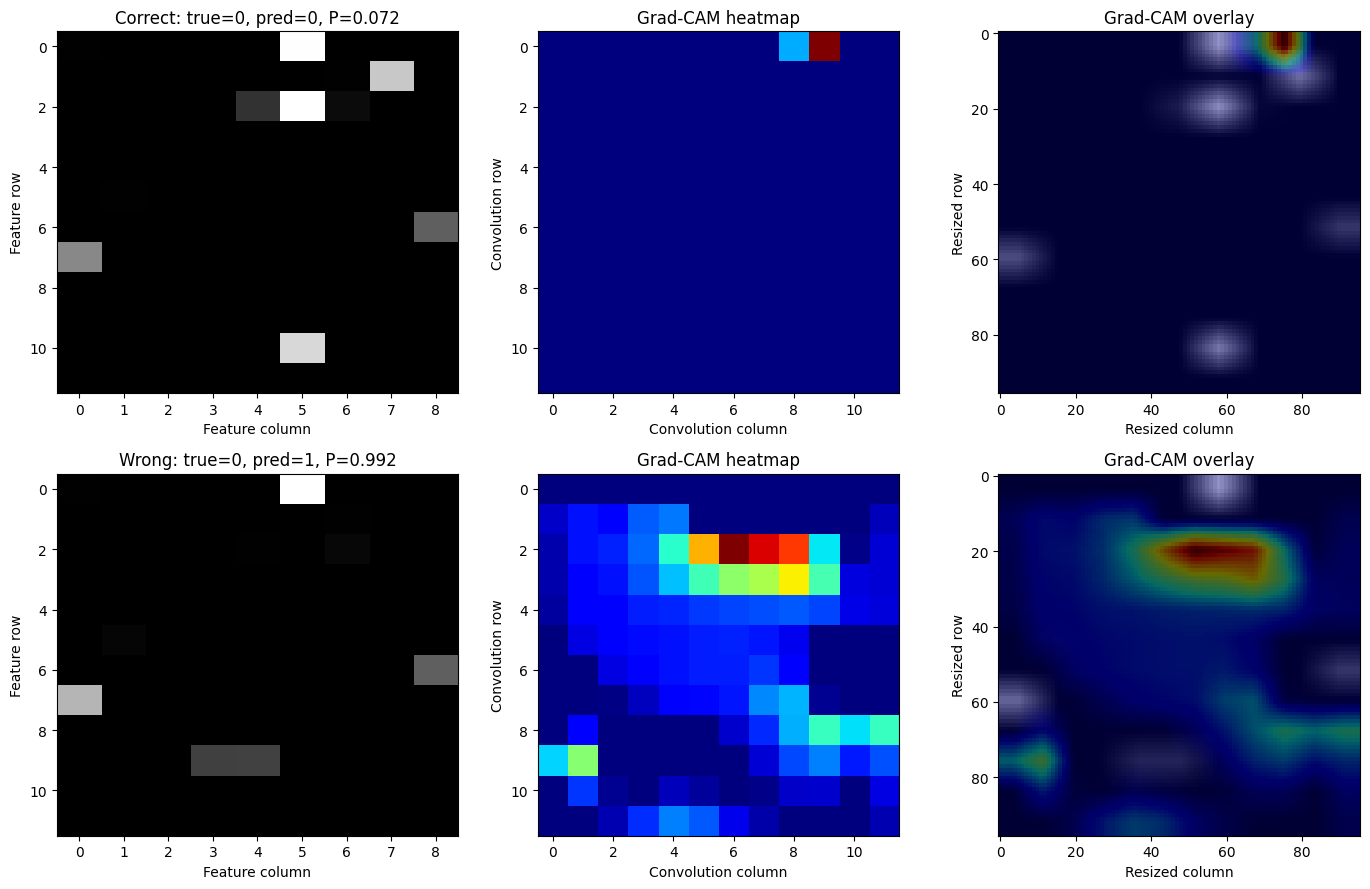

Reading: brighter Grad-CAM locations contributed more to the predicted class.
Limitation: locations are synthetic feature-grid positions, not natural malware regions.


In [11]:
# Grad-CAM for sigmoid binary classification
last_conv = [layer.name for layer in model.layers if isinstance(layer, layers.Conv2D)][-1]
grad_model = Model(model.input, [model.get_layer(last_conv).output, model.output])

def one_image(index):
    image, _ = preprocess_image(X_te_img[index], y_true[index], augment=False)
    return image.numpy()

def gradcam_heatmap(image, target_class):
    x = tf.convert_to_tensor(image[None], tf.float32)
    with tf.GradientTape() as tape:
        conv, pred = grad_model(x, training=False)
        score = pred[:,0] if target_class == 1 else 1.0 - pred[:,0]
    grads = tape.gradient(score, conv)
    weights = tf.reduce_mean(grads, axis=(1,2), keepdims=True)
    heat = tf.reduce_sum(weights * conv, axis=-1)[0]
    heat = tf.maximum(heat, 0); heat /= tf.reduce_max(heat) + 1e-8
    return heat.numpy()

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for row, (idx, label) in enumerate(cases):
    image = one_image(idx); heat = gradcam_heatmap(image, y_pred[idx])
    heat96 = tf.image.resize(heat[...,None], (IMG_SIZE,IMG_SIZE)).numpy()[...,0]
    axes[row,0].imshow(X_te_img[idx], cmap="gray", aspect="auto")
    axes[row,0].set_title(f"{label}: true={y_true[idx]}, pred={y_pred[idx]}, P={y_prob[idx]:.3f}")
    axes[row,0].set_xlabel("Feature column"); axes[row,0].set_ylabel("Feature row")
    axes[row,1].imshow(heat, cmap="jet"); axes[row,1].set_title("Grad-CAM heatmap")
    axes[row,1].set_xlabel("Convolution column"); axes[row,1].set_ylabel("Convolution row")
    axes[row,2].imshow(image/255.0); axes[row,2].imshow(heat96, cmap="jet", alpha=.42)
    axes[row,2].set_title("Grad-CAM overlay"); axes[row,2].set_xlabel("Resized column"); axes[row,2].set_ylabel("Resized row")
plt.tight_layout(); plt.savefig("Group04_SOMLAP_task3_gradcam.png", dpi=160, bbox_inches="tight"); plt.show()
print("Reading: brighter Grad-CAM locations contributed more to the predicted class.")
print("Limitation: locations are synthetic feature-grid positions, not natural malware regions.")

## LIME

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

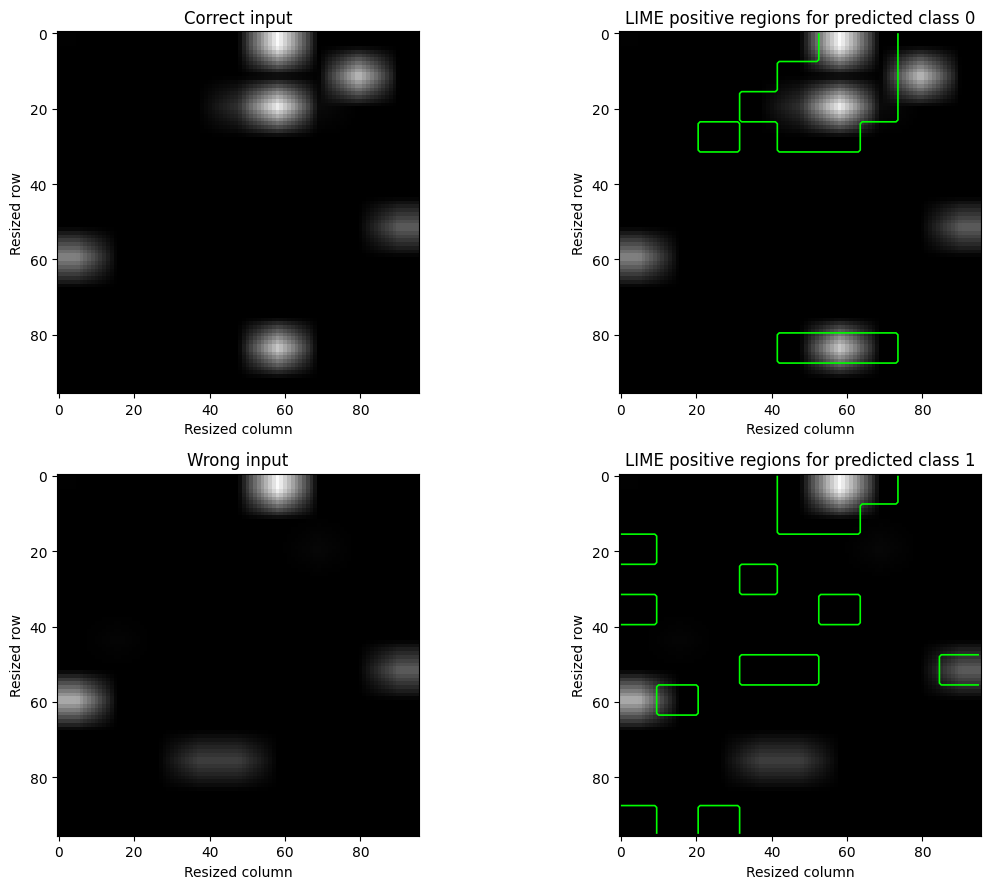

Top LIME features - Correct


,LIME weight
Maxpar,0.208280
majlv,0.173186
sig,0.131409
char,0.099024
Data_char,0.061561
ohs,0.058384
Idoem,0.050754
exehdradr,0.036477
ibase,0.030971
dbase,0.022172


Top LIME features - Wrong


,LIME weight
Maxpar,0.034058
Text_char,0.013014
Minpar,0.009814
Infoem,0.004180
Ivalss,0.003805
Idata_mscfaddr,0.002832
Idoem,0.002287
Text_ptrrawdat,0.001809
win32vv,0.001768
tds,0.001598


Reading: green-outlined grid cells support the predicted class locally; signs and magnitudes are sample-specific.
Limitation: LIME perturbs synthetic feature-grid cells, so it is not evidence of executable image regions.


In [12]:
# LIME with 108 fixed segments aligned to the original 12x9 feature grid
def grid_segments(image):
    h, w = image.shape[:2]; seg = np.zeros((h,w), dtype=np.int32)
    row_edges = np.linspace(0,h,IMG_H+1,dtype=int); col_edges = np.linspace(0,w,IMG_W+1,dtype=int)
    sid = 0
    for r in range(IMG_H):
        for c in range(IMG_W):
            seg[row_edges[r]:row_edges[r+1], col_edges[c]:col_edges[c+1]] = sid; sid += 1
    return seg

def lime_predict(images):
    arr = np.asarray(images, dtype=np.float32)
    if arr.max() <= 1.5: arr = arr * 255.0
    p = model.predict(arr, batch_size=64, verbose=0).ravel()
    return np.column_stack([1-p, p])

explainer = lime_image.LimeImageExplainer(random_state=SEED)
lime_results = []
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for row, (idx, label) in enumerate(cases):
    image = one_image(idx)
    explanation = explainer.explain_instance(image.astype(np.double), lime_predict,
        labels=(int(y_pred[idx]),), num_samples=1000, segmentation_fn=grid_segments,
        hide_color=0, random_seed=SEED)
    shown, mask = explanation.get_image_and_mask(int(y_pred[idx]), positive_only=True,
        num_features=15, hide_rest=False)
    axes[row,0].imshow(image/255.0); axes[row,0].set_title(f"{label} input")
    axes[row,0].set_xlabel("Resized column"); axes[row,0].set_ylabel("Resized row")
    axes[row,1].imshow(shown/255.0 if shown.max()>1.5 else shown)
    axes[row,1].contour(mask, levels=[0.5], colors="lime", linewidths=1.2)
    axes[row,1].set_title(f"LIME positive regions for predicted class {y_pred[idx]}")
    axes[row,1].set_xlabel("Resized column"); axes[row,1].set_ylabel("Resized row")
    weights = dict(explanation.local_exp[int(y_pred[idx])])
    feature_weights = pd.Series({list(X_train.columns)[sid]: weights.get(sid,0.0)
                                 for sid in range(IMG_H*IMG_W)}).sort_values(ascending=False)
    lime_results.append((label, feature_weights))
plt.tight_layout(); plt.savefig("Group04_SOMLAP_task3_lime.png", dpi=160, bbox_inches="tight"); plt.show()
for label, weights in lime_results:
    print("Top LIME features -", label); display(weights.head(15).to_frame("LIME weight"))
print("Reading: green-outlined grid cells support the predicted class locally; signs and magnitudes are sample-specific.")
print("Limitation: LIME perturbs synthetic feature-grid cells, so it is not evidence of executable image regions.")

## XAI interpretation

Grad-CAM and LIME describe model sensitivity within a synthetic 12×9 arrangement
of named PE features. The highlighted locations are not physical regions of a malware
executable. Agreement between the methods may support a local interpretation, but
neither method establishes causality.
